In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("cybersecurity_intrusion_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 1010.7 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session_id,9537,9537,SID_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network_packet_size,9537.0,NaN,NaN,NaN,500.430639,198.379364,64.0,365.0,499.0,635.0,1285.0
protocol_type,9537,3,TCP,6624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
login_attempts,9537.0,NaN,NaN,NaN,4.032086,1.963012,1.0,3.0,4.0,5.0,13.0
session_duration,9537.0,NaN,NaN,NaN,792.745312,786.560144,0.5,231.953006,556.277457,1105.380602,7190.392213
encryption_used,7571,2,AES,4706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_reputation_score,9537.0,NaN,NaN,NaN,0.331338,0.177175,0.002497,0.191946,0.314778,0.453388,0.924299
failed_logins,9537.0,NaN,NaN,NaN,1.517773,1.033988,0.0,1.0,1.0,2.0,5.0
browser_type,9537,5,Chrome,5137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unusual_time_access,9537.0,NaN,NaN,NaN,0.149942,0.357034,0.0,0.0,0.0,0.0,1.0


In [6]:
# Check duplicates (excluding identifier)
dupes = df.drop(columns=["session_id"]).duplicated().sum()
print("Fully duplicate rows (excl. session_id):", dupes)

# Missing values
print("\nMissing values per column:")
print(df.isna().sum())

Fully duplicate rows (excl. session_id): 0

Missing values per column:
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [7]:
# Fill missing encryption_used with an explicit 'None' category (no encryption)
df["encryption_used"] = df["encryption_used"].fillna("None")

# Confirm no missing values remain
print(df.isna().sum().sum(), "missing values remaining")
df["encryption_used"].value_counts()

0 missing values remaining


encryption_used
AES     4706
DES     2865
None    1966
Name: count, dtype: int64

In [8]:
model_df = df.drop(columns=["session_id"]).copy()
model_df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [9]:
#encoding
categorical_cols = ["protocol_type", "encryption_used", "browser_type"]
numeric_cols = ["network_packet_size", "login_attempts", "session_duration",
                 "ip_reputation_score", "failed_logins", "unusual_time_access"]

encoded_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=False)
# convert booleans from get_dummies to int for cleanliness
bool_cols = encoded_df.select_dtypes(include="bool").columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

print(encoded_df.shape)
encoded_df.head()

(9537, 18)


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,protocol_type_ICMP,protocol_type_TCP,protocol_type_UDP,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,599,4,492.983263,0.606818,1,0,1,0,1,0,0,1,0,0,1,0,0,0
1,472,3,1557.996461,0.301569,0,0,0,0,1,0,0,1,0,0,0,1,0,0
2,629,3,75.044262,0.739164,2,0,1,0,1,0,0,1,0,1,0,0,0,0
3,804,4,601.248835,0.123267,0,0,1,0,0,1,0,1,0,0,0,0,0,1
4,453,5,532.540888,0.054874,1,0,0,0,1,0,1,0,0,0,0,1,0,0


## 5. Normalizing Numeric Values

Numeric features are on very different scales (e.g., `session_duration` up to ~7190 vs `ip_reputation_score` between 0 and 1). This matters for **Logistic Regression** (a distance/coefficient-based model) but not for **Random Forest** (tree-based, scale-invariant).

We fit a `StandardScaler` on the numeric columns for the modeling pipeline, but keep an **unscaled copy** for the exported CSV so the data stays human-readable.


In [8]:
scaler = StandardScaler()
scaled_numeric = pd.DataFrame(
    scaler.fit_transform(encoded_df[numeric_cols]),
    columns=numeric_cols,
    index=encoded_df.index
)

scaled_df = encoded_df.copy()
scaled_df[numeric_cols] = scaled_numeric
scaled_df.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,protocol_type_ICMP,protocol_type_TCP,protocol_type_UDP,encryption_used_AES,encryption_used_DES,encryption_used_None,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,0.496899,-0.016346,-0.381125,1.554930,-0.500779,-0.419989,1,0,1,0,0,1,0,0,1,0,0,0
1,-0.143322,-0.525794,0.972960,-0.168029,-1.467959,-0.419989,0,0,1,0,0,1,0,0,0,1,0,0
2,0.648132,-0.525794,-0.912503,2.301950,0.466400,-0.419989,1,0,1,0,0,1,0,1,0,0,0,0
3,1.530327,-0.016346,-0.243473,-1.174443,-1.467959,-0.419989,1,0,0,1,0,1,0,0,0,0,0,1
4,-0.239103,0.493102,-0.330830,-1.560484,-0.500779,-0.419989,0,0,1,0,1,0,0,0,0,1,0,0


## 6. Correlation & Association Analysis

First, numeric-vs-numeric and numeric-vs-target correlation (Pearson), then a look at the one-hot encoded categorical features against the target.


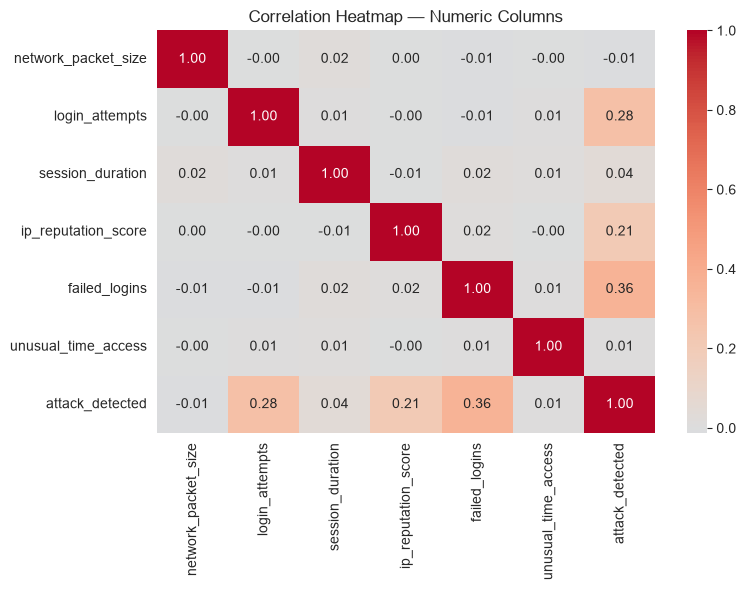

In [10]:
numeric_cols = ["network_packet_size", "login_attempts", "session_duration",
                 "ip_reputation_score", "failed_logins", "unusual_time_access", "attack_detected"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Columns")
plt.tight_layout()
plt.show()

In [17]:
df = df.drop(columns=['session_id'])
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'encryption_used', 'browser_type'], drop_first=False)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

Correlation with attack_detected (sorted by strength):

failed_logins           0.363726
login_attempts          0.277320
ip_reputation_score     0.211540
browser_type_Unknown    0.134630
session_duration        0.041602
browser_type_Chrome    -0.040087
encryption_used_AES    -0.020693
protocol_type_ICMP     -0.016619
encryption_used_None    0.016161
browser_type_Safari    -0.013289
browser_type_Firefox   -0.010556
unusual_time_access     0.008652
encryption_used_DES     0.008306
browser_type_Edge      -0.008057
protocol_type_UDP       0.007903
network_packet_size    -0.006798
protocol_type_TCP       0.000643
Name: attack_detected, dtype: float64


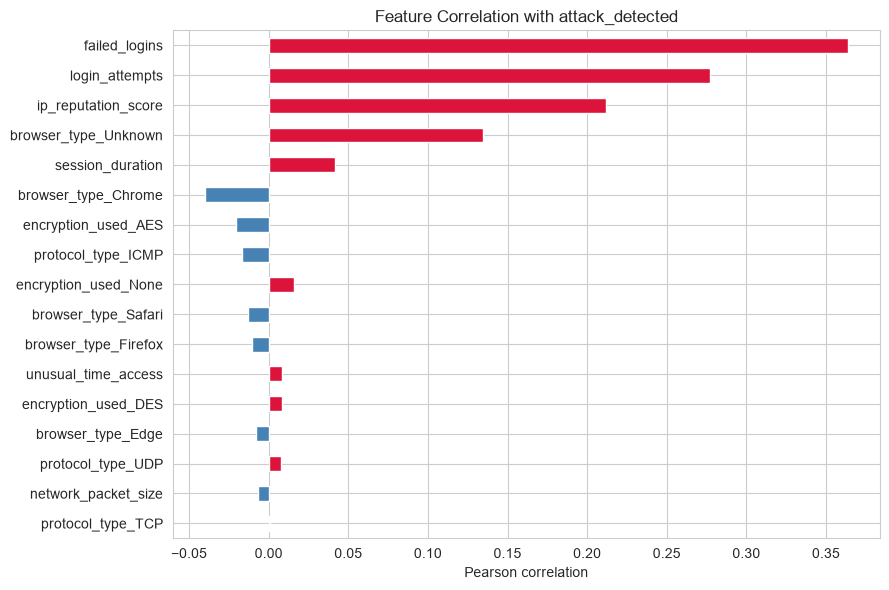

In [18]:
corr = df_encoded.corr()

target_corr = corr["attack_detected"].drop("attack_detected").sort_values(key=abs, ascending=False)
print("Correlation with attack_detected (sorted by strength):\n")
print(target_corr)

plt.figure(figsize=(9, 6))
target_corr.plot(kind="barh", color=(target_corr > 0).map({True: "crimson", False: "steelblue"}))
plt.title("Feature Correlation with attack_detected")
plt.xlabel("Pearson correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Train / Test Split

In [11]:
X = scaled_df.drop(columns=["attack_detected"])
y = scaled_df["attack_detected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))

Train shape: (7629, 17)  Test shape: (1908, 17)
Train target balance:
 attack_detected
0    0.55289
1    0.44711
Name: proportion, dtype: float64


## 8. Modeling

Two models are trained for comparison:
- **Logistic Regression** — interpretable baseline, coefficients show direction & relative strength of each predictor.
- **Random Forest** — captures non-linear relationships and feature interactions, gives a robust feature importance ranking.


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=None)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

def report(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 score :", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))
    print()

report("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
report("Random Forest", y_test, y_pred_rf, y_proba_rf)

--- Logistic Regression ---
Accuracy : 0.7285
Precision: 0.7173
Recall   : 0.6483
F1 score : 0.681
ROC-AUC  : 0.7876

--- Random Forest ---
Accuracy : 0.8826
Precision: 0.9861
Recall   : 0.7479
F1 score : 0.8507
ROC-AUC  : 0.8773



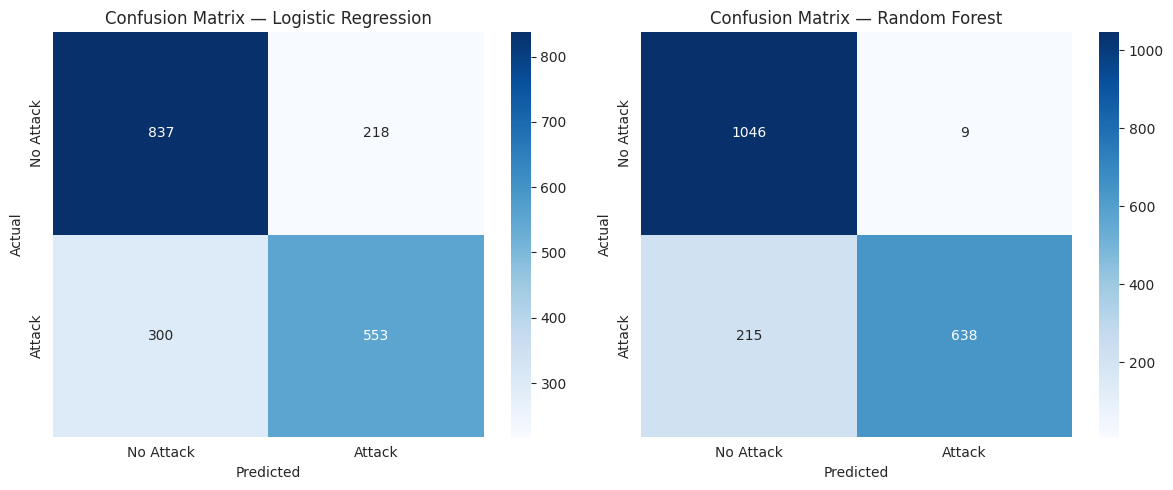

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Attack", "Attack"], yticklabels=["No Attack", "Attack"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

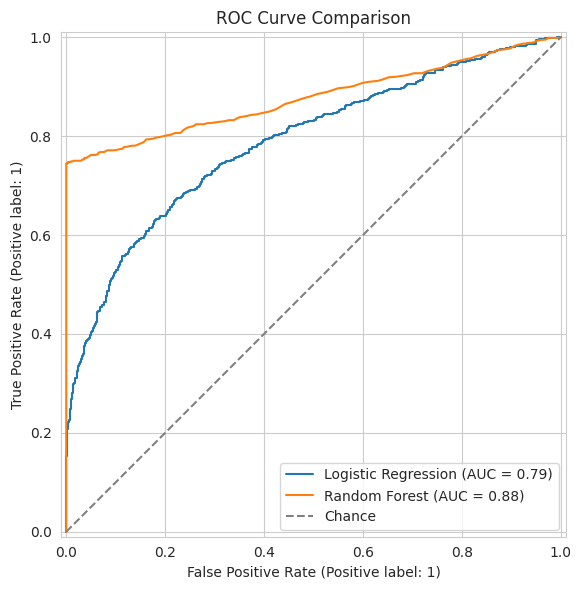

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance — The Strongest Predictors

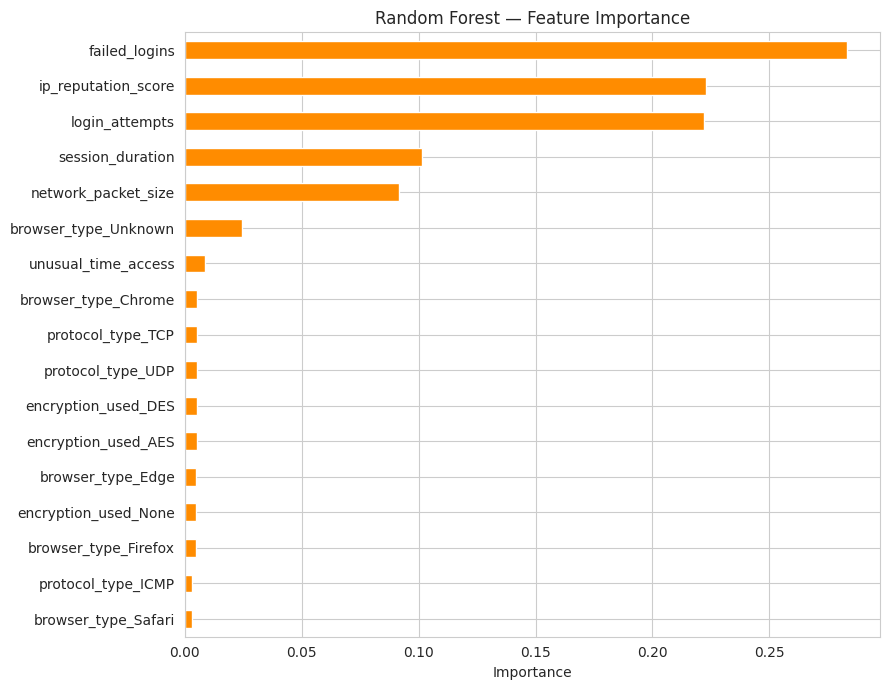

failed_logins           0.283165
ip_reputation_score     0.222890
login_attempts          0.222050
session_duration        0.101251
network_packet_size     0.091573
browser_type_Unknown    0.024531
unusual_time_access     0.008593
browser_type_Chrome     0.005330
protocol_type_TCP       0.005227
protocol_type_UDP       0.005115
encryption_used_DES     0.005014
encryption_used_AES     0.004993
browser_type_Edge       0.004738
encryption_used_None    0.004709
browser_type_Firefox    0.004692
protocol_type_ICMP      0.003252
browser_type_Safari     0.002877
dtype: float64

In [15]:
# Random Forest importance
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
rf_importance.plot(kind="barh", color="darkorange")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

rf_importance

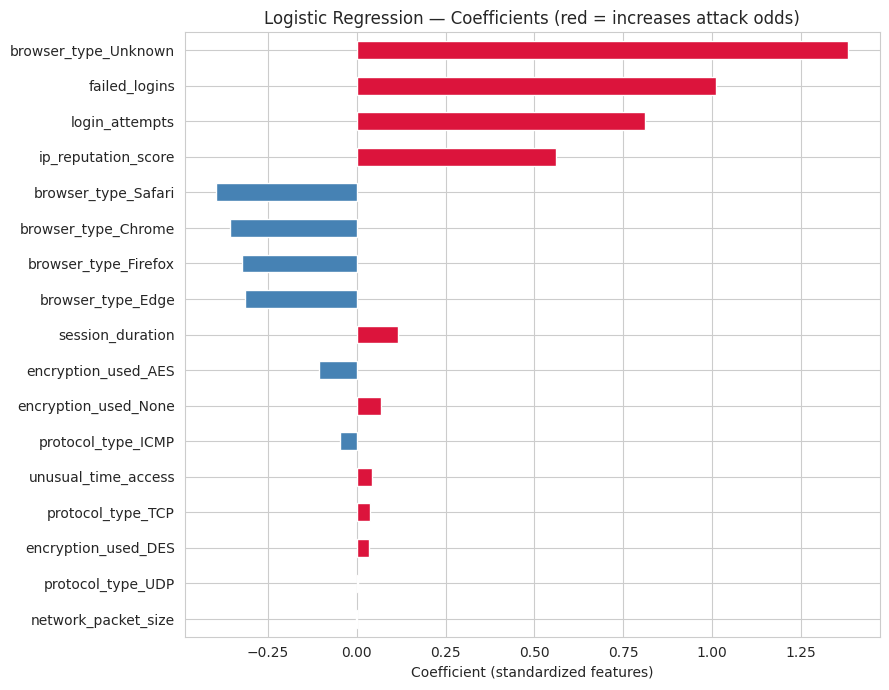

browser_type_Unknown    1.384722
failed_logins           1.012487
login_attempts          0.811647
ip_reputation_score     0.561165
browser_type_Safari    -0.395131
browser_type_Chrome    -0.356685
browser_type_Firefox   -0.324138
browser_type_Edge      -0.315235
session_duration        0.115173
encryption_used_AES    -0.106651
encryption_used_None    0.067055
protocol_type_ICMP     -0.047889
unusual_time_access     0.043579
protocol_type_TCP       0.037299
encryption_used_DES     0.033129
protocol_type_UDP       0.004123
network_packet_size    -0.001583
dtype: float64

In [16]:
# Logistic Regression coefficients (direction + magnitude)
lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 7))
colors = lr_coef.map(lambda v: "crimson" if v > 0 else "steelblue")
lr_coef.plot(kind="barh", color=colors)
plt.title("Logistic Regression — Coefficients (red = increases attack odds)")
plt.xlabel("Coefficient (standardized features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

lr_coef

**Result — Strongest predictors of a cybersecurity attack** (consistent across both correlation analysis and both models):

1. `failed_logins` — the single strongest signal; more failed logins strongly increases attack likelihood.
2. `login_attempts` — repeated login attempts is closely related and reinforces the brute-force pattern.
3. `session_duration` — unusually long/short sessions are associated with attacks.
4. `ip_reputation_score` — low-reputation source IPs are more likely tied to attacks.
5. `encryption_used_None` (no encryption) — sessions without encryption are riskier.
6. `unusual_time_access` — off-hours access adds meaningful signal, though weaker than the above.

`network_packet_size`, `protocol_type`, and `browser_type` contribute comparatively little on their own — they don't disappear from the model, but they rank consistently lower in both the correlation and importance results.


## 10. Export Final Cleaned Dataset

In [17]:
# Final cleaned dataset (human-readable, unscaled, cleaned) for export
final_export = model_df.copy()  # cleaned, missing values handled, session_id already dropped
final_export.insert(0, "session_id", df["session_id"])  # keep id back for reference

final_export.to_csv("cybersecurity_intrusion_data_cleaned.csv", index=False)
print("Saved:", final_export.shape)
final_export.head()

Saved: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## Summary

- **Goal chosen:** predicting `attack_detected` (Goal 2) — the dataset provides a clean, balanced, labeled target and behaviorally meaningful features, making it well-suited for supervised modeling with minimal noise.
- **Cleaning:** no duplicate rows; missing `encryption_used` values were recoded as an explicit `"None"` (no-encryption) category rather than dropped, preserving signal.
- **Feature selection:** all session-level columns were kept except the identifier `session_id`; correlation and model importance were used to *rank* relevance rather than to drop columns upfront.
- **Strongest predictors:** `failed_logins`, `login_attempts`, `session_duration`, `ip_reputation_score`, and lack of encryption — all confirmed by both correlation analysis and two independent models (Logistic Regression, Random Forest).
- **Model performance:** Random Forest and Logistic Regression results are reported above (accuracy, precision, recall, F1, ROC-AUC) — Random Forest generally captures the non-linear patterns slightly better, while Logistic Regression gives clean, interpretable coefficients confirming the same top predictors.
